# Uczenie Maszynowe

## Sprawozdanie - lab2: Modele liniowe: regresja liniowa i logistyczna

### Zadanie 1: Regresja i regularyzacja (zbiór WINE)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

### Wczytanie i wstępna analiza zbioru WINE

In [4]:
wine = load_wine()
df_wine = pd.DataFrame(wine.data, columns=wine.feature_names)

print("Kształt zbioru:", df_wine.shape)
print("\nCechy:")
print(df_wine.describe().round(2))

Kształt zbioru: (178, 13)

Cechy:
       alcohol  malic_acid     ash  alcalinity_of_ash  magnesium  \
count   178.00      178.00  178.00             178.00     178.00   
mean     13.00        2.34    2.37              19.49      99.74   
std       0.81        1.12    0.27               3.34      14.28   
min      11.03        0.74    1.36              10.60      70.00   
25%      12.36        1.60    2.21              17.20      88.00   
50%      13.05        1.87    2.36              19.50      98.00   
75%      13.68        3.08    2.56              21.50     107.00   
max      14.83        5.80    3.23              30.00     162.00   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count         178.00      178.00                178.00           178.00   
mean            2.30        2.03                  0.36             1.59   
std             0.63        1.00                  0.12             0.57   
min             0.98        0.34                  0.1

In [5]:
print("Brakujące wartości:")
print(df_wine.isnull().sum())

Brakujące wartości:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64


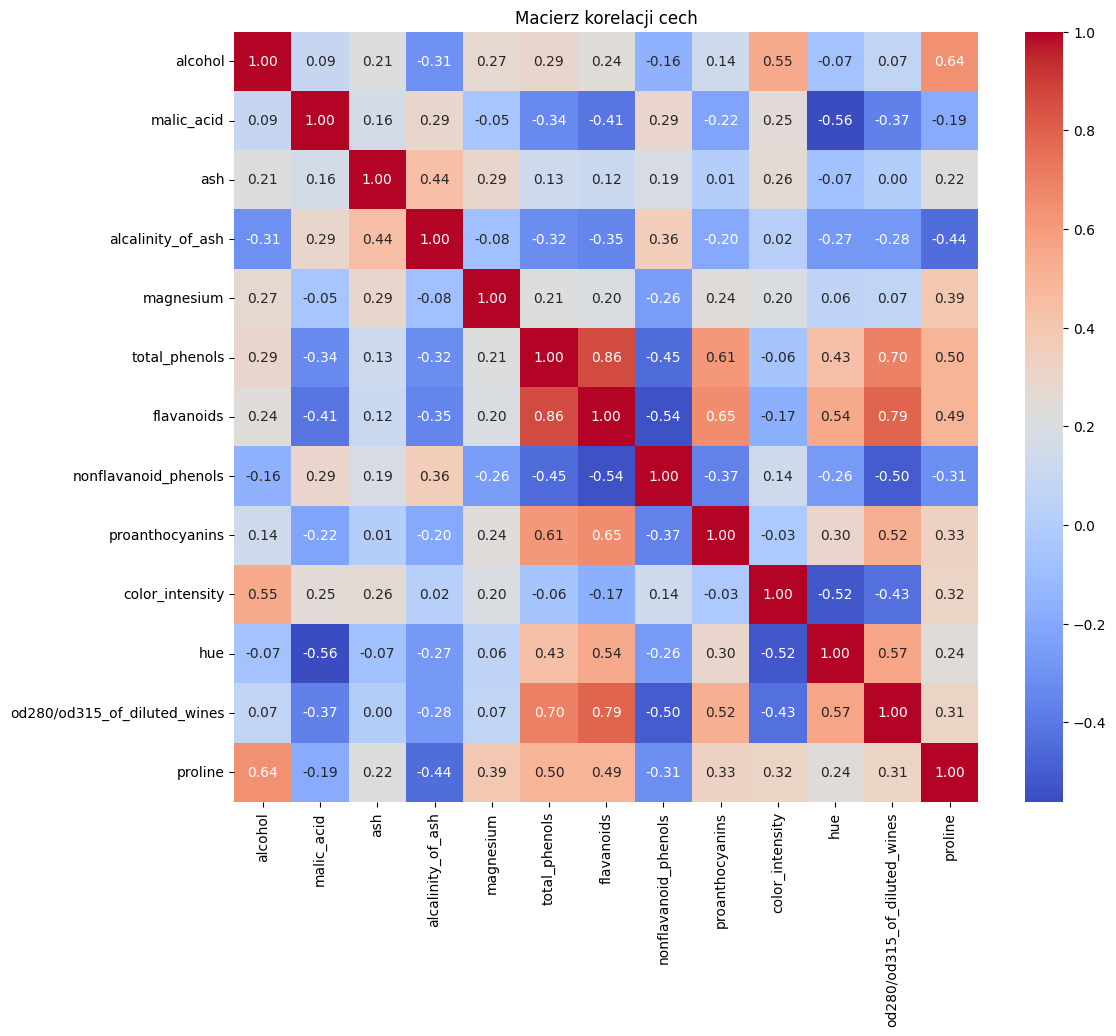

In [6]:
# macierz korelacji z wartościami (plot wraz z wartościami)
correlation_matrix = df_wine.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Macierz korelacji cech")
plt.show()

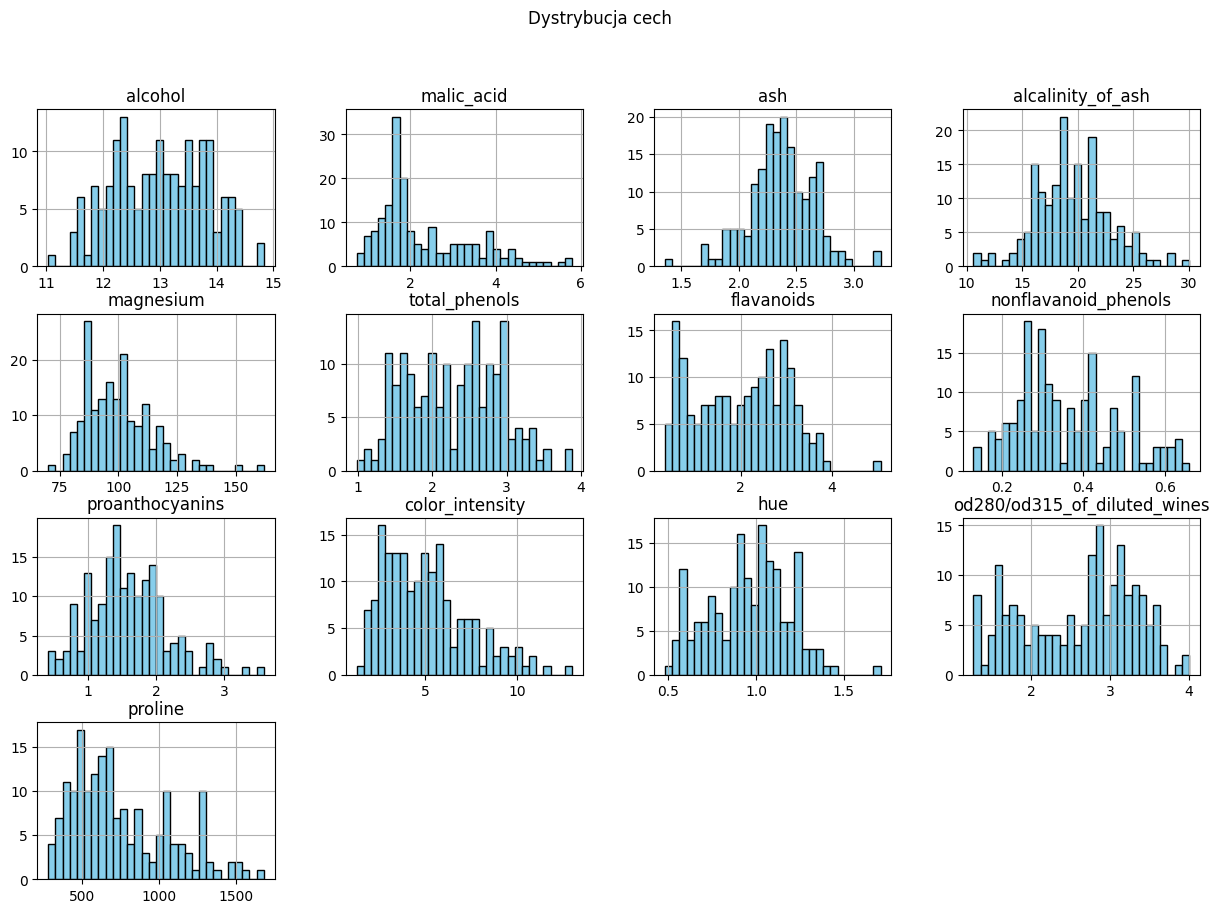

In [ ]:
# dystrybucja cech
df_wine.hist(bins=30, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.suptitle("Dystrybucja cech")
plt.show()

### Wybór zmiennej zaleznej (target)

In [7]:
TARGET = 'alcohol'

X_wine = df_wine.drop(columns=[TARGET])
y_wine = df_wine[TARGET]

print(f"Zmienna zależna: {TARGET}")
print(f"Zakres: {y_wine.min():.2f} – {y_wine.max():.2f}")
print(f"Średnia: {y_wine.mean():.2f}, Odch. std: {y_wine.std():.2f}")
print(f"\nLiczba cech predyktorów: {X_wine.shape[1]}")

Zmienna zależna: alcohol
Zakres: 11.03 – 14.83
Średnia: 13.00, Odch. std: 0.81

Liczba cech predyktorów: 12


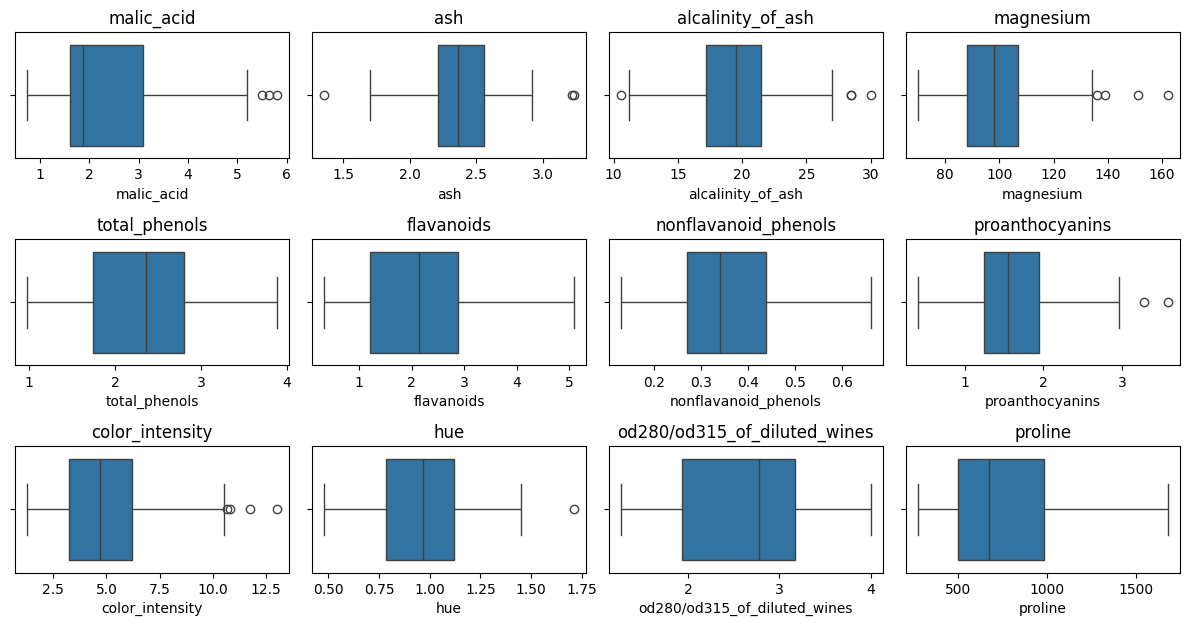

Liczba outlierów w każdej zmiennej:


,Zmienna,Liczba outlierów,Procent
0,malic_acid,3,1.69
1,ash,3,1.69
2,alcalinity_of_ash,4,2.25
3,magnesium,4,2.25
4,total_phenols,0,0.00
5,flavanoids,0,0.00
6,nonflavanoid_phenols,0,0.00
7,proanthocyanins,2,1.12
8,color_intensity,4,2.25
9,hue,1,0.56


In [ ]:
# sprawdzenie outlierów w zmiennych
plt.figure(figsize=(12, 8))
for i, column in enumerate(X_wine.columns):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(x=X_wine[column])
    plt.title(column)
plt.tight_layout()
plt.show()


outliers_count = {}

for column in X_wine.columns:
    Q1 = X_wine[column].quantile(0.25)
    Q3 = X_wine[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_count[column] = ((X_wine[column] < lower_bound) | (X_wine[column] > upper_bound)).sum()

outliers_df = pd.DataFrame(list(outliers_count.items()), columns=['Zmienna', 'Liczba outlierów'])
outliers_df['Procent'] = round((outliers_df['Liczba outlierów'] / len(X_wine)) * 100, 2)
print("Liczba outlierów w każdej zmiennej:")
outliers_df

In [177]:
from sklearn.base import BaseEstimator, TransformerMixin

class IQRClipper(BaseEstimator, TransformerMixin):
    def __init__(self, factor=3.5):
        self.factor = factor
    
    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        Q1 = X.quantile(0.25)
        Q3 = X.quantile(0.75)
        IQR = Q3 - Q1
        self.lower_ = Q1 - self.factor * IQR
        self.upper_ = Q3 + self.factor * IQR
        return self
    
    def transform(self, X, y=None):
        X = pd.DataFrame(X).copy()
        return X.clip(lower=self.lower_, upper=self.upper_, axis=1)

### Podział na zbiór treningowy i testowy

In [12]:
# bez stratyfikacji, bo target jest ciągły
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_wine, y_wine,
    test_size=0.2
)
print(f"Train: {X_train_w.shape[0]} próbek")
print(f"Test: {X_test_w.shape[0]} próbek")

Train: 142 próbek
Test: 36 próbek


### Model 1: Rergresja liniowa bez regularyzacji

In [15]:
wine_results = pd.DataFrame({
    'model': [],
    'R2_train': [],
    'R2_test': [],
    'R2_diff': [],
    'MSE_train': [],
    'MSE_test': [],
    'MSE_diff': []
})

wine_results_list = []

In [16]:
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

pipe_lr.fit(X_train_w, y_train_w)

y_pred_train_lr = pipe_lr.predict(X_train_w)
y_pred_test_lr = pipe_lr.predict(X_test_w)

r2_train_lr = r2_score(y_train_w, y_pred_train_lr)
r2_test_lr = r2_score(y_test_w,  y_pred_test_lr)
mse_train_lr = mean_squared_error(y_train_w, y_pred_train_lr)
mse_test_lr = mean_squared_error(y_test_w,  y_pred_test_lr)

wine_results_list.append({
    'model': 'LinearRegression',
    'R2_train': r2_train_lr,
    'R2_test': r2_test_lr,
    'MSE_train': mse_train_lr,
    'MSE_test': mse_test_lr,
})

print("Wyniki dla LinearRegression:")
print(f"R2 Train: {r2_train_lr:.4f}")
print(f"R2 Test: {r2_test_lr:.4f}")
print(f"MSE Train: {mse_train_lr:.4f}")
print(f"MSE Test: {mse_test_lr:.4f}")

Wyniki dla LinearRegression:
R2 Train: 0.6034
R2 Test: 0.5258
MSE Train: 0.2583
MSE Test: 0.3178


### Wizualizacja: predykcje vs rzeczywiste

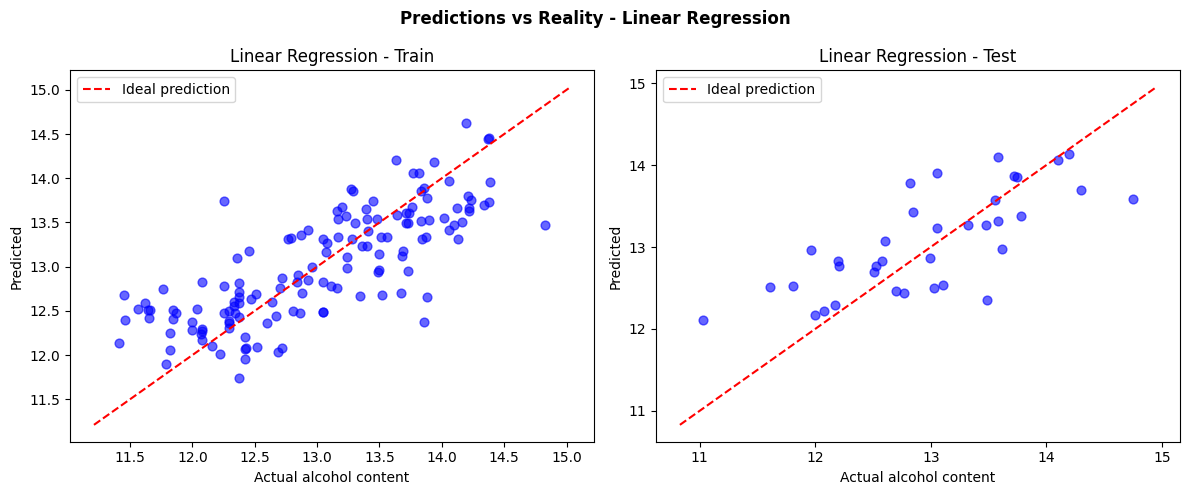

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_true, y_pred, split in [
    (axes[0], y_train_w, y_pred_train_lr, 'Train'),
    (axes[1], y_test_w,  y_pred_test_lr, 'Test')
]:
    ax.scatter(y_true, y_pred, alpha=0.6, color='blue', s=40)
    lims = [min(y_true.min(), y_pred.min()) - 0.2, max(y_true.max(), y_pred.max()) + 0.2]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Ideal prediction')
    ax.set_xlabel('Actual alcohol content')
    ax.set_ylabel('Predicted')
    ax.set_title(f'Linear Regression - {split}')
    ax.legend()

plt.suptitle('Predictions vs Reality - Linear Regression', fontweight='bold')
plt.tight_layout()
plt.show()

### Model 2 i 3: Ridge i Lasso - badanie wpływu alpha

In [18]:
alphas = np.logspace(-3, 3, 100)

ridge_coefs = []
lasso_coefs = []

for alpha in alphas:
    # Ridge
    pipe_r = Pipeline([
            ('sc', StandardScaler()), 
            ('m', Ridge(alpha=alpha))
        ])
    pipe_r.fit(X_train_w, y_train_w)
    ridge_coefs.append(pipe_r.named_steps['m'].coef_)

    # Lasso
    pipe_l = Pipeline([
            ('sc', StandardScaler()), 
            ('m', Lasso(alpha=alpha, max_iter=10000))
        ])
    pipe_l.fit(X_train_w, y_train_w)
    lasso_coefs.append(pipe_l.named_steps['m'].coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

alfa (alpha) to siła regularyzacji:
- alfa=0: brak regularyzacji (identyczne z LinearRegression)
- duże alfa: silna kara, współczynniki zmierzają do zera

Ridge (L2): minimalizuje sumę kwadratów wag — wagi maleją ale nigdy nie zerują się całkowicie

Lasso (L1): minimalizuje sumę wartości bezwzględnych wag — wagi mogą wyzerować się całkowicie (selekcja cech)

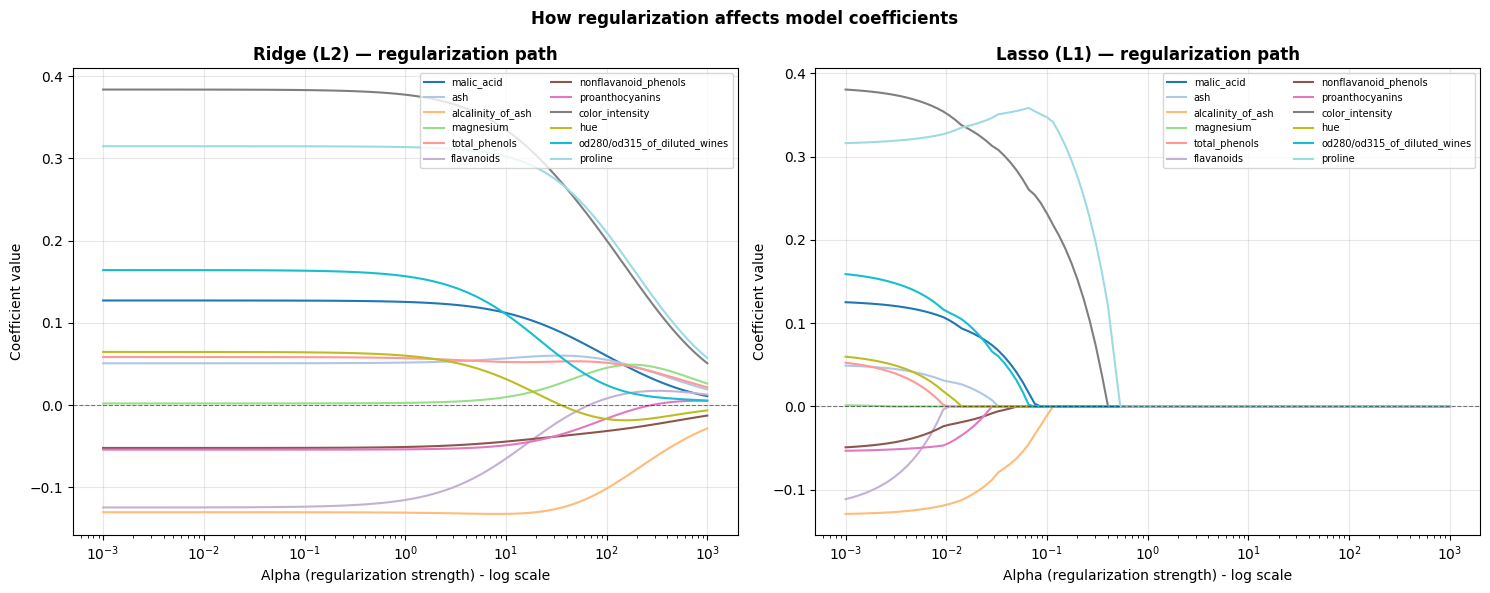

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

feature_names = X_wine.columns.tolist()
colors_path = plt.cm.tab20(np.linspace(0, 1, len(feature_names)))

for ax, coefs, title in [
    (axes[0], ridge_coefs, 'Ridge (L2) — regularization path'),
    (axes[1], lasso_coefs, 'Lasso (L1) — regularization path')
]:
    for i, (name, color) in enumerate(zip(feature_names, colors_path)):
        ax.plot(alphas, coefs[:, i], color=color, lw=1.5, label=name)
    ax.set_xscale('log')
    ax.set_xlabel('Alpha (regularization strength) - log scale')
    ax.set_ylabel('Coefficient value')
    ax.set_title(title, fontweight='bold')
    ax.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.5)
    ax.legend(fontsize=7, loc='upper right', ncol=2)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    'How regularization affects model coefficients',
    fontweight='bold'
)
plt.tight_layout()
plt.show()

Ridge: wszystkie cechy pozostają w modelu, wagi maleją proporcjonalnie

Lasso: część cech zostaje całkowicie wyzerowana przy wystarczająco dużym alpha

Lasso działa jak automatyczna selekcja cech — eliminuje nieistotne predyktory

### Porównanie metryk dla róznych wartości alpha

In [20]:
results_reg = []

for alpha in [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]:
    for ModelClass, name in [(Ridge, 'Ridge'), (Lasso, 'Lasso')]:
        pipe = Pipeline([
            ('sc', StandardScaler()),
            ('m', ModelClass(alpha=alpha, max_iter=10000))
        ])
        pipe.fit(X_train_w, y_train_w)
        mse_train = mean_squared_error(y_train_w, pipe.predict(X_train_w))
        mse_test = mean_squared_error(y_test_w, pipe.predict(X_test_w))
        r2_train = r2_score(y_train_w, pipe.predict(X_train_w))
        r2_test = r2_score(y_test_w, pipe.predict(X_test_w))
        results_reg.append({
            'Model': name,
            'Alpha': alpha,
            'R2_train': r2_train,
            'R2_test': r2_test,
            'MSE_train': mse_train,
            'MSE_test': mse_test,
            'n_zero_coefs': int(np.sum(np.abs(pipe.named_steps['m'].coef_) < 1e-6))
        })

df_reg = pd.DataFrame(results_reg)
print("Wpływ alfa na metryki:")
df_reg

Wpływ alfa na metryki:


,Model,Alpha,R2_train,R2_test,MSE_train,MSE_test,n_zero_coefs
0,Ridge,0.001,0.603412,0.525818,0.258298,0.317763,0
1,Lasso,0.001,0.603349,0.529499,0.258339,0.315297,0
2,Ridge,0.010,0.603412,0.525846,0.258298,0.317745,0
3,Lasso,0.010,0.597491,0.555490,0.262155,0.297880,3
4,Ridge,0.100,0.603412,0.526123,0.258298,0.317559,0
5,Lasso,0.100,0.529951,0.513106,0.306144,0.326282,9
6,Ridge,1.000,0.603353,0.528679,0.258336,0.315847,0
7,Lasso,1.000,0.000000,-0.002319,0.651301,0.671684,12
8,Ridge,10.000,0.599857,0.541339,0.260614,0.307363,0
9,Lasso,10.000,0.000000,-0.002319,0.651301,0.671684,12


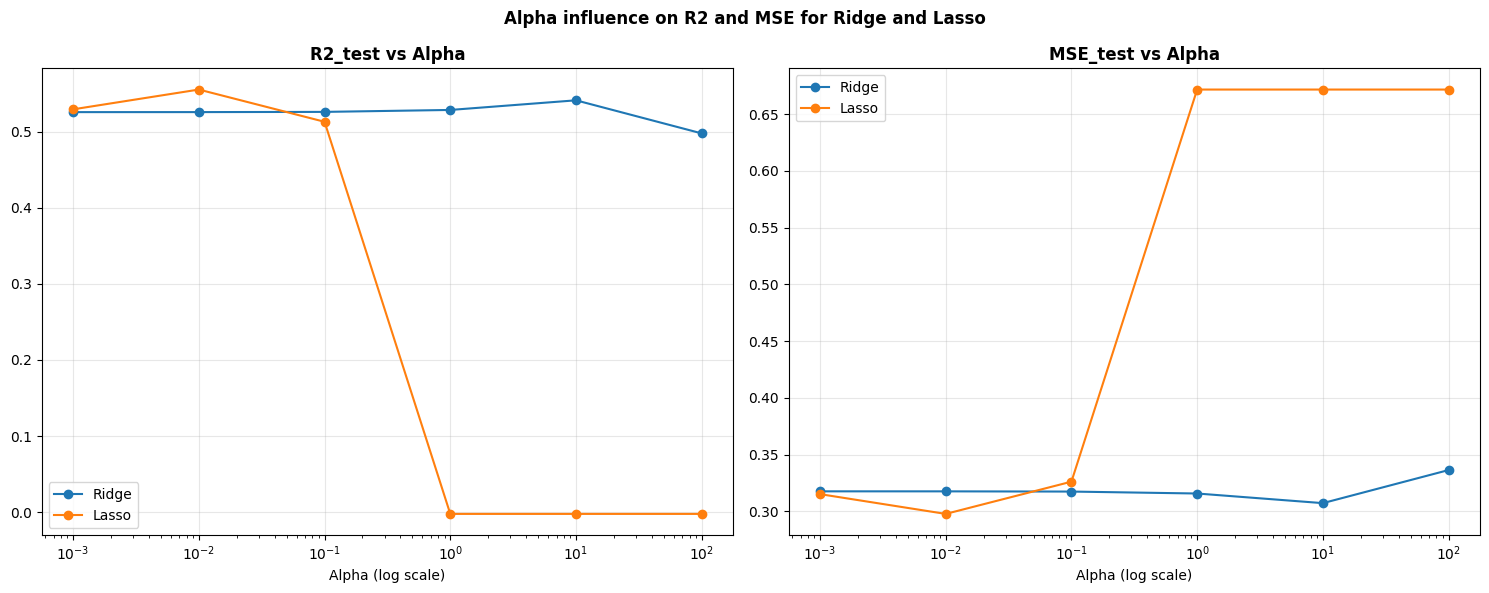

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, metric in zip(axes, ['R2_test', 'MSE_test']):
    for model in ['Ridge', 'Lasso']:
        subset = df_reg[df_reg['Model'] == model]
        ax.plot(subset['Alpha'], subset[metric], marker='o', label=model)
    ax.set_xscale('log')
    ax.set_xlabel('Alpha (log scale)')
    ax.set_title(f'{metric} vs Alpha', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle('Alpha influence on R2 and MSE for Ridge and Lasso', fontweight='bold')
plt.tight_layout()
plt.show()

### Walidacja krzyzowa - wyznaczenie optymalnego alfa

In [13]:
cv = KFold(n_splits=6, shuffle=True)
alphas_cv_ridge = np.logspace(-2, 3, 1000)
alphas_cv_lasso = np.logspace(-4, 1, 2000)

# RidgeCV i LassoCV robią CV wewnętrznie
ridge_cv = Pipeline([
    ('sc', StandardScaler()),
    ('m', RidgeCV(alphas=alphas_cv_ridge, cv=cv))
])
ridge_cv.fit(X_train_w, y_train_w)
best_alpha_ridge = ridge_cv.named_steps['m'].alpha_

lasso_cv = Pipeline([
    ('sc', StandardScaler()),
    ('m', LassoCV(alphas=alphas_cv_lasso, cv=cv, max_iter=10000))
])
lasso_cv.fit(X_train_w, y_train_w)
best_alpha_lasso = lasso_cv.named_steps['m'].alpha_

print(f"Optymalne alpha (Ridge CV): {best_alpha_ridge:.4f}")
print(f"Optymalne alpha (Lasso CV): {best_alpha_lasso:.4f}")

print("\nPorównanie ręcznego alpha=1.0 i 0.07 vs CV:")
for name, pipe_cv, best_alpha in [
    ('Ridge', ridge_cv, best_alpha_ridge),
    ('Lasso', lasso_cv, best_alpha_lasso)
]:
    r2_cv = r2_score(y_test_w, pipe_cv.predict(X_test_w))

    pipe_manual = Pipeline([
        ('sc', StandardScaler()),
        ('m', Ridge(alpha=1.0) if name == 'Ridge' else Lasso(alpha=0.015))
    ])
    pipe_manual2 = Pipeline([
        ('sc', StandardScaler()),
        ('m', Ridge(alpha=0.0) if name == 'Ridge' else Lasso(alpha=0.0))
    ])
    pipe_manual.fit(X_train_w, y_train_w)
    pipe_manual2.fit(X_train_w, y_train_w)
    r2_manual = r2_score(y_test_w, pipe_manual.predict(X_test_w))
    r2_manual_2 = r2_score(y_test_w, pipe_manual2.predict(X_test_w))

    if name == 'Ridge':
        print(f"    {name}: alpha_CV={best_alpha:.4f} -> R2={r2_cv:.4f} | alpha=1.0 -> R2={r2_manual:.4f} | alpha=0.0 -> R2={r2_manual_2:.4f}")
    else:
        print(f"    {name}: alpha_CV={best_alpha:.4f} -> R2={r2_cv:.4f} | alpha=0.015 -> R2={r2_manual:.4f} | alpha=0.0 -> R2={r2_manual_2:.4f}")

Optymalne alpha (Ridge CV): 21.0535
Optymalne alpha (Lasso CV): 0.0276

Porównanie ręcznego alpha=1.0 i 0.07 vs CV:
    Ridge: alpha_CV=21.0535 -> R2=0.5435 | alpha=1.0 -> R2=0.5287 | alpha=0.0 -> R2=0.5258
    Lasso: alpha_CV=0.0276 -> R2=0.5453 | alpha=0.015 -> R2=0.5524 | alpha=0.0 -> R2=0.5258


### Zestawienie końcowe - wszystkie modele

In [22]:
all_models = [
    ('LinearRegression', pipe_lr),
    (f'Ridge (alpha={best_alpha_ridge:.3f} CV)', ridge_cv),
    (f'Lasso (alpha={best_alpha_lasso:.3f} CV)', lasso_cv),
]

wine_results_list.append({
    'model': f'Ridge (alpha={best_alpha_ridge:.3f} CV)',
    'R2_train': r2_score(y_train_w, ridge_cv.predict(X_train_w)),
    'R2_test': r2_score(y_test_w, ridge_cv.predict(X_test_w)),
    'MSE_train': mean_squared_error(y_train_w, ridge_cv.predict(X_train_w)),
    'MSE_test': mean_squared_error(y_test_w, ridge_cv.predict(X_test_w)),
})

wine_results_list.append({
    'model': f'Lasso (alpha={best_alpha_lasso:.3f} CV)',
    'R2_train': r2_score(y_train_w, lasso_cv.predict(X_train_w)),
    'R2_test': r2_score(y_test_w, lasso_cv.predict(X_test_w)),
    'MSE_train': mean_squared_error(y_train_w, lasso_cv.predict(X_train_w)),
    'MSE_test': mean_squared_error(y_test_w, lasso_cv.predict(X_test_w)),
})

wine_results = pd.DataFrame(wine_results_list)
wine_results

,model,R2_train,R2_test,MSE_train,MSE_test
0,LinearRegression,0.603412,0.525815,0.258298,0.317765
1,Ridge (alpha=21.053 CV),0.592799,0.543519,0.265210,0.305902
2,Lasso (alpha=0.028 CV),0.585212,0.545278,0.270152,0.304723


## Zadanie 2 - Regresja logistyczna na zbiorze Bankruptcy

In [118]:
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, roc_auc_score,
    roc_curve, classification_report
)

In [119]:
PALETTE = {1: 'red', 0: 'green'}

In [130]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
polish_companies_bankruptcy = fetch_ucirepo(id=365) 
  
# data (as pandas dataframes) 
X_b = polish_companies_bankruptcy.data.features
y_b = polish_companies_bankruptcy.data.targets

In [132]:
df_b_all = X_b.copy()
df_b_all['class'] = y_b['class']
df_b_all

,year,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,A56,A57,A58,A59,A60,A61,A62,A63,A64,class
0,1,0.200550,0.37951,0.396410,2.04720,32.3510,0.38825,0.249760,1.33050,1.13890,...,0.121960,0.397180,0.87804,0.001924,8.4160,5.1372,82.658,4.4158,7.42770,0
1,1,0.209120,0.49988,0.472250,1.94470,14.7860,0.00000,0.258340,0.99601,1.69960,...,0.121300,0.420020,0.85300,0.000000,4.1486,3.2732,107.350,3.4000,60.98700,0
2,1,0.248660,0.69592,0.267130,1.55480,-1.1523,0.00000,0.309060,0.43695,1.30900,...,0.241140,0.817740,0.76599,0.694840,4.9909,3.9510,134.270,2.7185,5.20780,0
3,1,0.081483,0.30734,0.458790,2.49280,51.9520,0.14988,0.092704,1.86610,1.05710,...,0.054015,0.142070,0.94598,0.000000,4.5746,3.6147,86.435,4.2228,5.54970,0
4,1,0.187320,0.61323,0.229600,1.40630,-7.3128,0.18732,0.187320,0.63070,1.15590,...,0.134850,0.484310,0.86515,0.124440,6.3985,4.3158,127.210,2.8692,7.89800,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43400,5,0.012898,0.70621,0.038857,1.17220,-18.9070,0.00000,0.013981,0.41600,1.67680,...,0.020169,0.043904,1.01220,1.259400,13.4720,12.4320,49.117,7.4313,2.27990,1
43401,5,-0.578050,0.96702,-0.800850,0.16576,-67.3650,-0.57805,-0.578050,-0.40334,0.93979,...,-0.064073,1.482000,1.06410,-0.018084,110.7200,44.7590,81.220,4.4940,5.13050,1
43402,5,-0.179050,1.25530,-0.275990,0.74554,-120.4400,-0.17905,-0.154930,-0.26018,1.17490,...,0.148880,0.548240,0.85112,-0.522430,9.8526,3.4892,207.870,1.7559,9.95270,1
43403,5,-0.108860,0.74394,0.015449,1.08780,-17.0030,-0.10886,-0.109180,0.12531,0.84516,...,-0.183200,-1.167700,1.18320,6.092400,13.8860,6.0769,83.122,4.3911,0.95575,1


In [133]:
SELECTED_YEAR = 4

df_b = df_b_all[df_b_all['year'] == SELECTED_YEAR]
df_b.drop(columns=['year'], inplace=True)
df_b.reset_index(drop=True, inplace=True)
df_b

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,A56,A57,A58,A59,A60,A61,A62,A63,A64,class
0,0.159290,0.46240,0.077730,1.16830,-44.8530,0.467020,0.189480,0.82895,1.12230,0.38330,...,0.108990,0.415570,0.89101,0.001422,7.7928,4.9914,119.810,3.0465,3.05600,0
1,-0.127430,0.46243,0.269170,1.75170,7.5970,0.000925,-0.127430,1.16250,1.29440,0.53757,...,-0.089372,-0.237040,1.06250,0.150410,5.4327,3.4629,100.970,3.6150,3.47250,0
2,0.070488,0.23570,0.527810,3.23930,125.6800,0.163670,0.086895,2.87180,1.05740,0.67689,...,0.054286,0.104130,0.94571,0.000000,7.1070,3.3808,76.076,4.7978,4.78180,0
3,0.136760,0.40538,0.315430,1.87050,19.1150,0.504970,0.136760,1.45390,1.11440,0.58938,...,0.102630,0.232030,0.89737,0.073024,6.1384,4.2241,88.299,4.1337,4.64840,0
4,-0.110080,0.69793,0.188780,1.27130,-15.3440,0.000000,-0.110080,0.43282,1.73500,0.30207,...,0.439880,-0.364400,0.57153,0.000000,18.8010,2.7925,146.390,2.4934,15.03600,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9787,0.004676,0.54949,0.192810,1.38990,-39.0640,0.004676,0.013002,0.78627,0.97093,0.43205,...,-0.029937,0.010823,1.02990,0.127190,3.8159,3.3892,146.860,2.4854,3.93150,1
9788,-0.027610,0.60748,-0.029762,0.90591,-20.9230,-0.027610,-0.027610,0.55161,1.00730,0.33509,...,0.007198,-0.082395,0.99280,0.868910,23.0280,27.1360,37.047,9.8523,4.36810,1
9789,-0.238290,0.62708,0.090374,1.61250,-1.0692,-0.238290,-0.240360,0.28322,0.80307,0.17760,...,-0.245220,-1.341700,1.24520,2.700100,6.5694,4.1781,88.883,4.1065,0.79501,1
9790,0.097188,0.75300,-0.327680,0.43850,-214.2400,-0.331300,0.104280,0.32803,0.98145,0.24700,...,0.288240,0.393470,0.68127,0.508850,4.3246,35.5030,217.030,1.6818,1.31910,1


In [134]:
X_b = df_b.drop(columns=['class'])
y_b = df_b['class']
X_b.reset_index(drop=True, inplace=True)
y_b.reset_index(drop=True, inplace=True)

len_dataset = len(X_b)
print(f'Shape of X: {X_b.shape}')
print(f'Shape of y: {y_b.shape}')
print(f'Bankrupt: {y_b.sum()} ({(y_b.sum() / len_dataset * 100):.2f}%)')
print(f'Non-bankrupt: {len_dataset - y_b.sum()} ({((len_dataset - y_b.sum()) / len_dataset * 100):.2f}%)')
print(f'Missing values in X: {X_b.isnull().sum().sum()} ({(X_b.isnull().sum().sum() / (len_dataset * X_b.shape[1]) * 100):.2f}%)')
print(f'Missing values in y: {y_b.isnull().sum()} ({(y_b.isnull().sum() / len_dataset * 100):.2f}%)')

Shape of X: (9792, 64)
Shape of y: (9792,)
Bankrupt: 515 (5.26%)
Non-bankrupt: 9277 (94.74%)
Missing values in X: 8776 (1.40%)
Missing values in y: 0 (0.00%)


### Preprocessing

In [135]:
# modyfikacja cech na podstawie poprzedniej listy
X_b_feat = X_b.drop(columns=['A37'])
X_b_feat['missing_count'] = X_b.isnull().sum(axis=1)

Podział ze stratyfikacją

In [245]:
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_b_feat, y_b,
    test_size=0.2,
    stratify=y_b
)
print(f"Train: {X_train_b.shape[0]} firm, bankruci: {y_train_b.sum()} ({100*y_train_b.mean():.1f}%)")
print(f"Test: {X_test_b.shape[0]} firm, bankruci: {y_test_b.sum()} ({100*y_test_b.mean():.1f}%)")

Train: 7833 firm, bankruci: 412 (5.3%)
Test: 1959 firm, bankruci: 103 (5.3%)


Dalsza część preprocessingu

In [246]:
prep_pipeline = Pipeline([
    ('clipper', IQRClipper(factor=3.5)),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

X_train_prep = prep_pipeline.fit_transform(X_train_b)
X_test_prep  = prep_pipeline.transform(X_test_b)

In [249]:
# model bazowy: Regresja logistyczna
# C: parametr regularyzacji w LogisticRegression
# C = 1/alpha — im mniejsze C, tym silniejsza regularyzacja
pipe_logreg = Pipeline([
    ('model', LogisticRegression(
        class_weight='balanced',
        C=1.0,
        max_iter=1000
    ))
])

pipe_logreg.fit(X_train_prep, y_train_b)

y_pred_b = pipe_logreg.predict(X_test_prep)
y_proba_b = pipe_logreg.predict_proba(X_test_prep)[:, 1]

precision_b = precision_score(y_test_b, y_pred_b)
recall_b = recall_score(y_test_b, y_pred_b)
roc_auc_b = roc_auc_score(y_test_b, y_proba_b)

print("Wyniki regresji logistycznej (C=1.0, balanced):")
print(f"- Precision: {precision_b:.4f}")
print(f"- Recall:   {recall_b:.4f}")
print(f"- AUC-ROC:  {roc_auc_b:.4f}")

Wyniki regresji logistycznej (C=1.0, balanced):
- Precision: 0.1513
- Recall:   0.7184
- AUC-ROC:  0.8270


### Macierz pomyłek

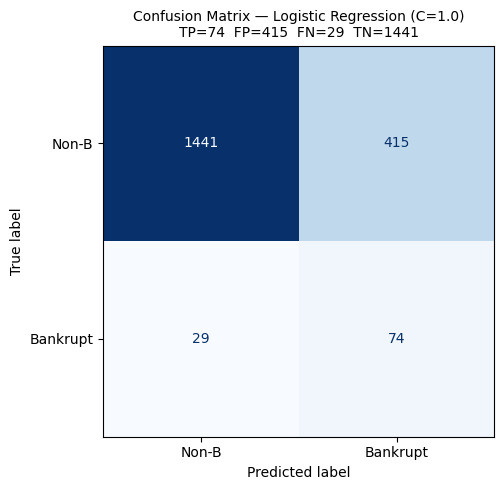

Precision: 0.1513
Recall: 0.7184


In [250]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test_b, y_pred_b)
ConfusionMatrixDisplay(cm, display_labels=['Non-B', 'Bankrupt']).plot(
    ax=ax, colorbar=False, cmap='Blues'
)
tn, fp, fn, tp = cm.ravel()
ax.set_title(
    f'Confusion Matrix — Logistic Regression (C=1.0)\n'
    f'TP={tp}  FP={fp}  FN={fn}  TN={tn}',
    fontsize=10
)
plt.tight_layout()
plt.show()

print(f'Precision: {precision_b:.4f}')
print(f'Recall: {recall_b:.4f}')

TP: bankruci poprawnie wykryci

FN: bankruci przeoczeni (najgroźniejszy błąd)

FP: fałszywe alarmy (zdrowe firmy uznane za bankrutów)

TN: zdrowe firmy poprawnie odrzucone

### Analiza wag modelu

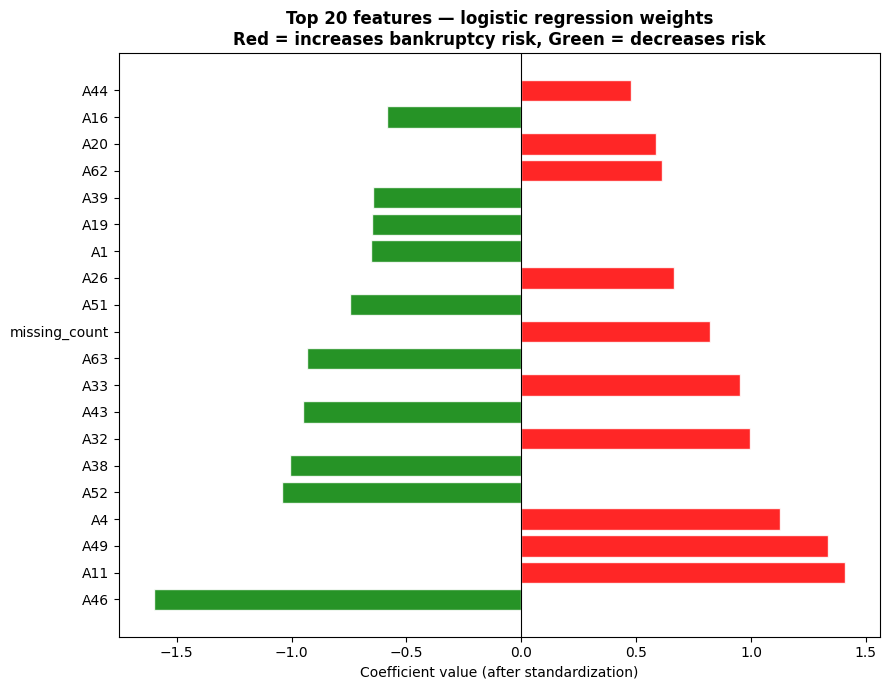

Top 10 features increasing bankruptcy risk (positive weights):
      Feature  Coefficient
          A11     1.410718
          A49     1.335726
           A4     1.125156
          A32     0.993745
          A33     0.949953
missing_count     0.821627
          A26     0.663176
          A62     0.614466
          A20     0.586899
          A44     0.478151

Top 10 features decreasing bankruptcy risk (negative weights):
Feature  Coefficient
    A46    -1.600698
    A52    -1.042906
    A38    -1.007616
    A43    -0.950011
    A63    -0.932924
    A51    -0.746122
     A1    -0.653457
    A19    -0.651904
    A39    -0.645874
    A16    -0.585809


In [252]:
feature_names_b = X_b_feat.columns.tolist()
coef = pipe_logreg.named_steps['model'].coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names_b,
    'Coefficient': coef
}).sort_values('Coefficient', key=abs, ascending=False)

top_n = 20
top_coef = coef_df.head(top_n)

fig, ax = plt.subplots(figsize=(9, 7))
colors_coef = ['red' if v > 0 else 'green' for v in top_coef['Coefficient']]
ax.barh(top_coef['Feature'], top_coef['Coefficient'],
        color=colors_coef, edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Coefficient value (after standardization)')
ax.set_title(f'Top {top_n} features — logistic regression weights\n'
             f'Red = increases bankruptcy risk, Green = decreases risk',
             fontweight='bold')
plt.tight_layout()
plt.show()

print("Top 10 features increasing bankruptcy risk (positive weights):")
print(coef_df[coef_df['Coefficient'] > 0].head(10).to_string(index=False))
print("\nTop 10 features decreasing bankruptcy risk (negative weights):")
print(coef_df[coef_df['Coefficient'] < 0].head(10).to_string(index=False))

Zmienne zwiększające ryzyko:

| Cecha | Znaczenie / Wzór | Interpretacja | Intuicyjna ocena sensowności ekonomicznej |
|:---|:---|:---|:---|
| A11 | (zysk + rózne dodatki) / akywa | ile firma zarabia względem tego, co posiada | sens |
| A49 | EBITDA / sprzedaz (marza operacyjna) | ile firma zarabia na sprzedazy (przed kosztami typu amortyzacja) | sens |
| A4 | aktywa obrotowe / zobowiązania krótkoterminowe (current ratio) | czy firma jest w stanie spłacić krótkoterminowe długi | troche średnio |
| A32 | (obecne zobowiązania * 365) / koszty produkcji | jak długo firma zwleka ze spłatą dostawców (w dniach) | bardzo duzy sens |
| A33 | kozsty operacyjne / zobowiązania krótkoterminowe | czy firma ma duzo kosztów względem tego, co musi szybko spłacić | sensowne |
| missing_count | liczba braków danych w instancji | - | bardzo sensowne |
| A26 | (zysk + amortyzacja) / zobowiązania | czy firma generuje cashflow względem długów | dziwne |
| A62 | (zobowiązania krótkoterminowe * 365) / sprzedaz | jak długo "wiszą" zobowiązania względem sprzedazy | sensowne |
| A20 | (zapasy * 365) / sprzedaz | ile dni towar lezy w magazynie | sensowne |
| A44 | (nalezności * 365) / sprzedaz | ile dni klienci nie płacą | sensowne |

Zmienne zmniejszające ryzyko:

| Cecha | Znaczenie / Wzór | Interpretacja | Intuicyjna ocena sensowności ekonomicznej |
|:---|:---|:---|:---|
| A46 | (aktywa obrotowe – zapasy) / zobowiązania krótkoterminowe (quick ratio) | czy firma ma „prawdziwą” płynność (bez zapasów) | bardzo sensowne |
| A52 | (krótkoterminowe zobowiązania * 365) / koszty produkcji | jak długo firma zwleka ze spłatą dostawców (w dniach) | mały sens (podobne do A32) |
| A38 | kapitał stały / aktywa | jak duzo firmy finansuje się stabilnym kapitałem | sensowne |
| A43 | rotacja zalezności + zapasów (dni) | jak długo trwa cały cykl operacyjny | cięzko stwierdzić |
| A63 | sprzedaz / zobowiązania krótkoterminowe | czy firma zarabia duzo względem długów | sensowne |
| A51 | zobowiązania krótkoterminowe / aktywa | jak bardzo firma jest zadłuzona krótkoterminowo | mało sensowne |
| A1 | zysk / aktywa | czy firma dobrze wykorzystuje majątek | bardzo sensowne |
| A19, A39 | marze (zysk / sprzedaz) | czy firma zarabia na sprzedazy | sensowne |
| A16 | (zysk + amortyzacja) / zobowiązania | czy firma generuje środki vs długi | sensowne |


### Badanie wpływu progu klasyfikacji

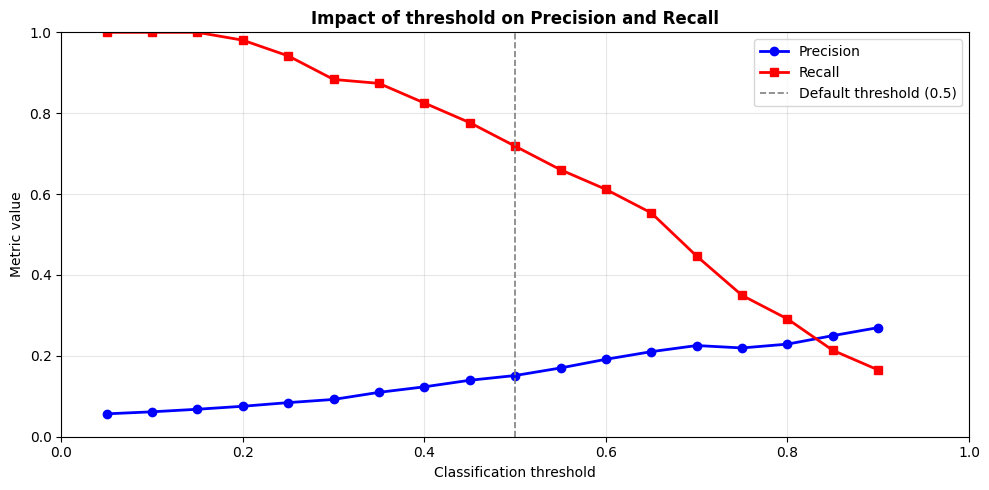

Przy domyślnym progu 0.5:
Precision=0.151, Recall=0.718


In [ ]:
thresholds = np.arange(0.05, 0.95, 0.05)
thresh_results = []

for thresh in thresholds:
    y_pred_t = (y_proba_b >= thresh).astype(int)
    tp_t = ((y_pred_t == 1) & (y_test_b == 1)).sum()
    fp_t = ((y_pred_t == 1) & (y_test_b == 0)).sum()
    fn_t = ((y_pred_t == 0) & (y_test_b == 1)).sum()
    thresh_results.append({
        'threshold': thresh,
        'precision': precision_score(y_test_b, y_pred_t, zero_division=0),
        'recall': recall_score(y_test_b, y_pred_t, zero_division=0),
        'TP': tp_t, 'FP': fp_t, 'FN': fn_t
    })

df_thresh = pd.DataFrame(thresh_results)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_thresh['threshold'], df_thresh['precision'],'o-', color='blue', lw=2, label='Precision')
ax.plot(df_thresh['threshold'], df_thresh['recall'],'s-', color='red', lw=2, label='Recall')
ax.axvline(0.5, color='gray', linestyle='--', lw=1.2, label='Default threshold (0.5)')

ax.set_xlabel('Classification threshold')
ax.set_ylabel('Metric value')
ax.set_title('Impact of threshold on Precision and Recall', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1])
plt.tight_layout()
plt.show()

print(f"Przy domyślnym progu 0.5:")
row_05 = df_thresh[df_thresh['threshold'].round(2) == 0.50].iloc[0]
print(f"Precision={row_05['precision']:.3f}, Recall={row_05['recall']:.3f}")

Zmniejszanie progu -> zwiększanie alertów ze ktoś bankrut -> większy recall i mniejsza precyzja

### Krzywa ROC

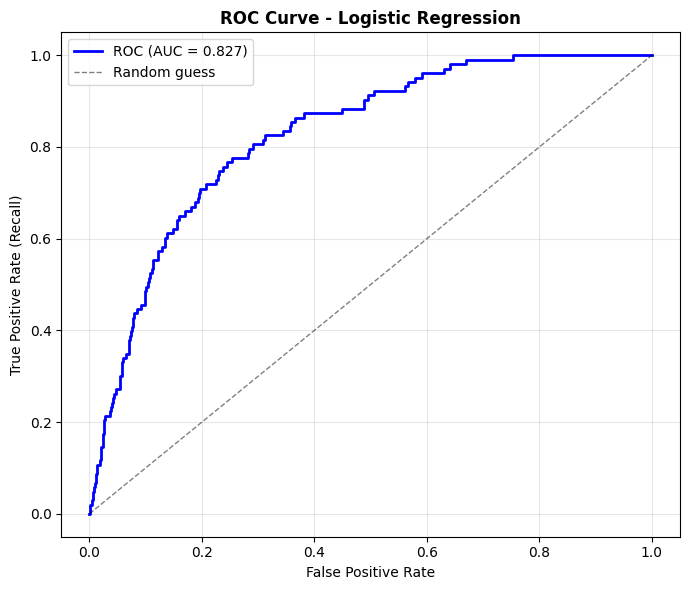

In [256]:
fpr, tpr, roc_thresh = roc_curve(y_test_b, y_proba_b)
auc = roc_auc_score(y_test_b, y_proba_b)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='blue', lw=2, label=f'ROC (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curve - Logistic Regression', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fpr -> ile fałszywych alarmów

### Badanie parametru regularyzacji C

C = 1/alpha

małe C -> silna regularyzacja (mnejsze wagi, prostszy model)

duze C -> słaba regularyzacja

solver='saga' obsługuje zarówno L1 jak i L2 

In [ ]:
C_values = np.logspace(-4, 3, 13)
reg_results = []

for penalty in ['l2', 'l1']:
    for C in C_values:
        model = Pipeline([
            ('m', LogisticRegression(
                l1_ratio=1 if penalty == 'l1' else 0,
                C=C,
                class_weight='balanced',
                solver='saga',
                max_iter=1000
            ))
        ])
        model.fit(X_train_prep, y_train_b)
        y_pred_c = model.predict(X_test_prep)
        y_proba_c = model.predict_proba(X_test_prep)[:, 1]

        coefs = model.named_steps['m'].coef_[0]
        reg_results.append({
            'regularization': penalty.upper(),
            'C': C,
            'precision': precision_score(y_test_b, y_pred_c, zero_division=0),
            'recall': recall_score(y_test_b, y_pred_c, zero_division=0),
            'AUC': roc_auc_score(y_test_b, y_proba_c),
            'n_zero': int(np.sum(np.abs(coefs) < 1e-6))
        })

df_reg_b = pd.DataFrame(reg_results)
df_reg_b

,regularization,C,precision,recall,AUC,n_zero
0,L2,0.000100,0.118677,0.592233,0.743048,0
1,L2,0.000383,0.131115,0.650485,0.775569,0
2,L2,0.001468,0.147638,0.728155,0.805501,0
3,L2,0.005623,0.145263,0.669903,0.822209,0
4,L2,0.021544,0.146091,0.689320,0.829349,0
5,L2,0.082540,0.160356,0.699029,0.830479,0
6,L2,0.316228,0.142035,0.718447,0.816277,0
7,L2,1.211528,0.142276,0.679612,0.815068,0
8,L2,4.641589,0.150495,0.737864,0.825358,0
9,L2,17.782794,0.157080,0.689320,0.827848,0


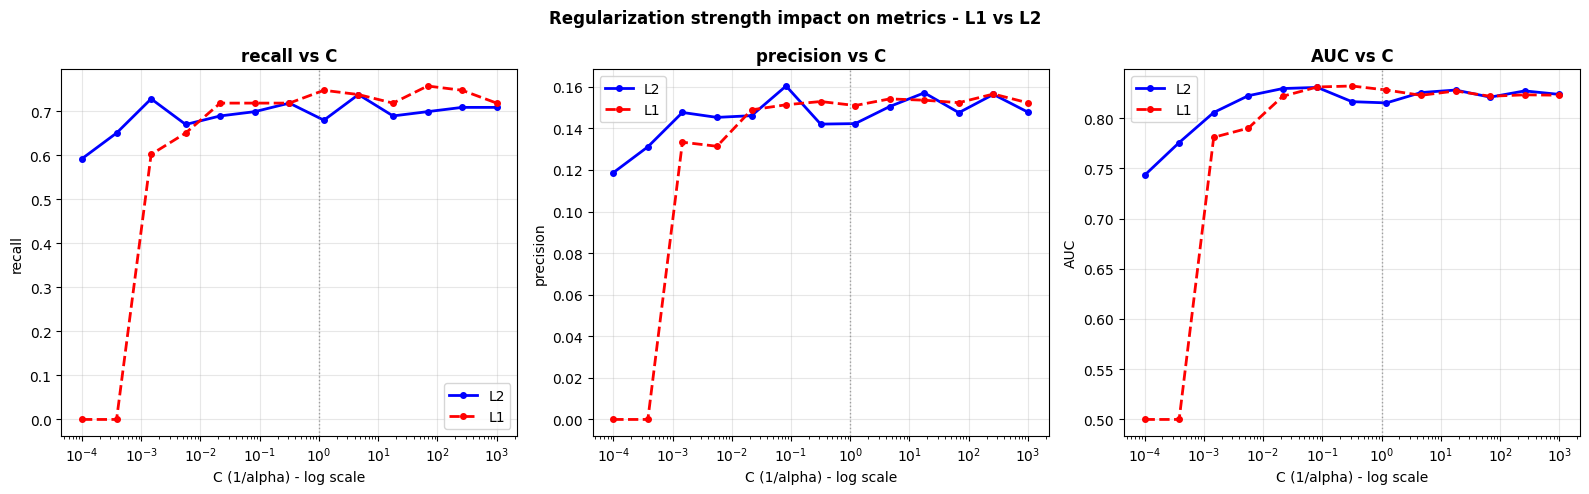

In [273]:
# Wykres metryk w funkcji C
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, ['recall', 'precision', 'AUC']):
    for penalty, color, ls in [('L2', 'blue', '-'), ('L1', 'red', '--')]:
        subset = df_reg_b[df_reg_b['regularization'] == penalty]
        ax.plot(subset['C'], subset[metric],
                color=color, linestyle=ls, lw=2,
                marker='o', markersize=4, label=penalty)
    ax.set_xscale('log')
    ax.set_xlabel('C (1/alpha) - log scale')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} vs C', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axvline(1.0, color='gray', linestyle=':', lw=1, alpha=0.7)

plt.suptitle(
    'Regularization strength impact on metrics - L1 vs L2', fontweight='bold'
)
plt.tight_layout()
plt.show()

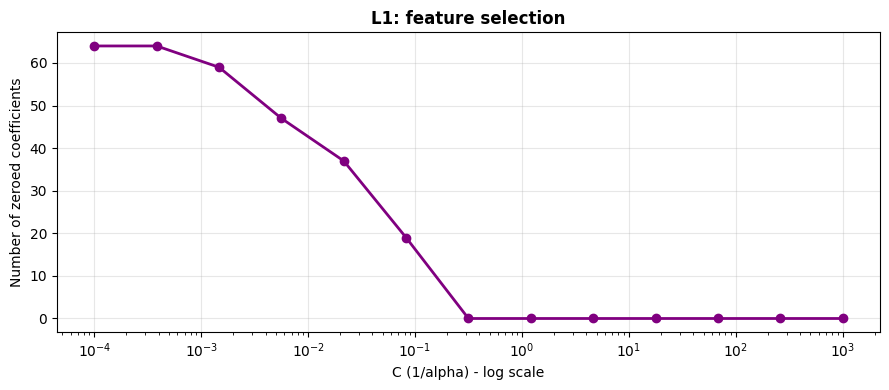

In [274]:
# Wykres selekcji cech przez L1 (analogia do Lasso)
l1_subset = df_reg_b[df_reg_b['regularization'] == 'L1']

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(l1_subset['C'], l1_subset['n_zero'], 'o-', color='purple', lw=2)
ax.set_xscale('log')
ax.set_xlabel('C (1/alpha) - log scale')
ax.set_ylabel('Number of zeroed coefficients')
ax.set_title('L1: feature selection', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Obserwacje:

- L1 (analogia Lasso): przy małym C wiele cech zostaje wyzerowanych
- L2 (analogia Ridge): przy małym C wagi maleją ale nigdy nie zerują się
- to jest bezpośrednia analogia do ścieżki regularyzacji z zadania 1

Pytania:

1. Dlaczego skalowanie jest krytyczne dla Lasso/Ridge a nie dla drzew?

Lasso i Ridge karzą model za duze współczynniki. Koszt = Błąd + alfa * (suma kar za współczynniki). Jeśli cechy mają inne zakresy, to zeby miały taki sam wpływ na predykcję część z nich będzie miało większy współczynnik, ale nie dlatego ze są wazniejsze, tylko z konieczności. Efekt -> regularyzacja nieproporcjonlanie karze cechy o małej skali. Po standaryzacji std=1, więc wspólczynniki są porównywalne i kara jest sprawiedliwa.

Drzewo decyzyjne pyta tylko "czy dana wartość cechy X jest większa od zadnaego progu", czyli wazny jest tylko porządek obserwacji. Skalowanie nie jest az tak wazne, bo utrzymuje ten porządek. 

2. L1 vs L2

L1 (Lasso) minimalizuje sume wartości bezwzględnych współczynników, L2 (Ridge) sumę kwadratów współczynników. Pochodna kary względem współczynnika dla L1 jest stała - niezalezy od wartości współczynnika, przy wystarczająco małych wartościach współczynnika ten impuls ciągnący w stronę zera jest silniejszy niz sygnał z danych i model go zeruje. W L2 pochodzna kary jest zalezna od wartości współczynnika. dązy do zera, ale nie zostaną one wyzerowane 

3. Accuracy dla niezbalansowanych danych

Poniewaz accuracy mówi o liczbie wszystkich poprawnych odpowiedzi razem (poprawne 1 i poprawne 0), to gdy w zbiorze jest 95% wartości 1 a nasz model zawsze będzie zakładał wartość 1, to dostaniemy 95% accuracy, mimo ze nasz "model" ignoruje zupełnie inną klasę.

Regresja logistyczna zwraca prawdopodobieństwo przynalezności do odpowiedniej klasy. Ze względu na niski procent bankrutów, model rzadko moze przekraczac domyślne 0.5 na bankruta - jest ich mało i model chce bezpiecznie być ostrozny z alarmami. Jednak w zalezności od naszego celu, zadania w którym model będzie wykorzystywany, mozemy chcieć zaby wyłapywał więcej bankrutów kosztem większej liczby fałszywych alarmów - do tego moze słuzyć analiza progu prawdopodobieństwa, który pokazuje jak będzie zachowywał się model gdy np. obnizymy pewność



In [275]:
# Zestawienie końcowe
print("Regresja Logistyczna na zbiorze Bankruptcy")
print(f"{'Model':<30} {'Precision':>10} {'Recall':>8} {'AUC':>8}")

for desc, C, penalty in [
    ('L2, C=1.0 (domyślny)', 1.0, 'l2'),
    (f'L2, C optymalne (CV)', None, 'l2'),
    ('L1, C=1.0', 1.0, 'l1'),
    (f'L1, C optymalne (CV)', None, 'l1'),
]:
    if C is None:
        # znajdź C które daje najwyższy AUC dla L2
        best_row = df_reg_b[df_reg_b['regularization']=='L2'].loc[
            df_reg_b[df_reg_b['regularization']=='L2']['AUC'].idxmax()
        ]
        C = best_row['C']
        desc = f'L2, C={C:.3f} (najlepsze AUC)'
        # C najlepsze dla L1
        best_row_l1 = df_reg_b[df_reg_b['regularization']=='L1'].loc[
            df_reg_b[df_reg_b['regularization']=='L1']['AUC'].idxmax()
        ]
        C_l1 = best_row_l1['C']
        if penalty == 'l1':
            C = C_l1
            desc = f'L1, C={C:.3f} (najlepsze AUC)'

    model_f = LogisticRegression(
        l1_ratio=1 if penalty == 'l1' else 0, C=C, class_weight='balanced',
        solver='saga', max_iter=1000
    )
    model_f.fit(X_train_prep, y_train_b)
    yp = model_f.predict(X_test_prep)
    ya = model_f.predict_proba(X_test_prep)[:, 1]
    print(f"{desc:<30} "
          f"{precision_score(y_test_b, yp, zero_division=0):>10.4f} "
          f"{recall_score(y_test_b, yp, zero_division=0):>8.4f} "
          f"{roc_auc_score(y_test_b, ya):>8.4f}")

Regresja Logistyczna na zbiorze Bankruptcy
Model                           Precision   Recall      AUC
L2, C=1.0 (domyślny)               0.1553   0.6602   0.8045
L2, C=0.083 (najlepsze AUC)        0.1485   0.7282   0.8250
L1, C=1.0                          0.1501   0.6311   0.8170
L1, C=0.316 (najlepsze AUC)        0.1507   0.7476   0.8391
